In [1]:
import pandas as pd
import glob
file = glob.glob('*silver*.csv')[0]
print(f"Found: {file}")
df = pd.read_csv(file)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
print(f"Rows: {len(df)} | From {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Found: silver_daily_ohlcv_2000_2025 (1).csv
Rows: 6783 | From 2000-01-03 to 2025-12-31


,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,Dollar_Change,Intraday_Range,Intraday_Range_Pct
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,-0.0090,0.0078,0.1511
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,-0.0930,0.0236,0.4649
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,0.0432,0.0076,0.1472
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,0.0826,0.0168,0.3225
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,0.0540,0.0066,0.1251


✅ 20 Indicators Created
        Close     SMA_20     RSI_14      MACD   BB_Upper  Volatility_20
6778  37.4841  34.904535  83.665213  0.631811  37.631945       0.015459
6779  37.7450  35.113665  85.800545  0.724982  38.041798       0.012820
6780  38.6309  35.365680  85.416354  0.860387  38.594084       0.013323
6781  37.1281  35.526965  66.596420  0.836787  38.769836       0.016899
6782  36.9662  35.688335  65.805037  0.795847  38.877298       0.016886


/tmp/ipykernel_439/1526226957.py:53: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df['Close'].dropna())
/tmp/ipykernel_439/1526226957.py:57: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result2 = adfuller(df['Log_Return'].dropna())



ADF Test on Close: Statistic=-1.3062, p-value=0.626346
Non-Stationary (need differencing)
ADF Test on Log_Return: Statistic=-82.7324, p-value=0.000000
✅ Stationary - Good for modeling


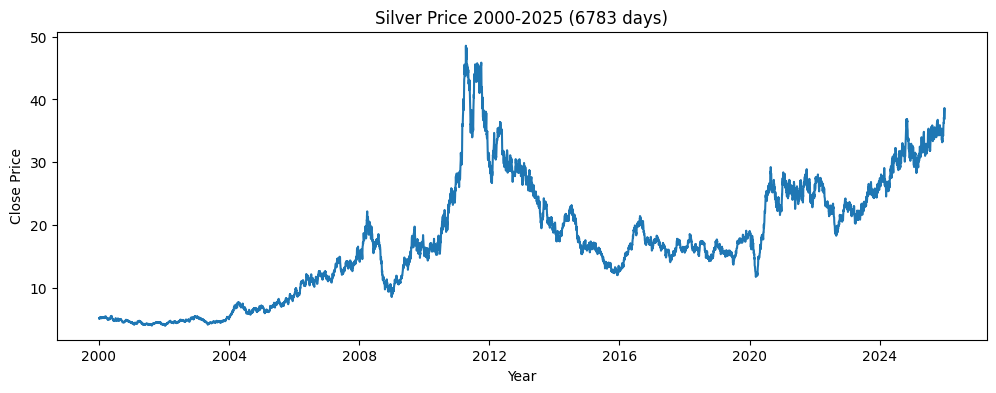

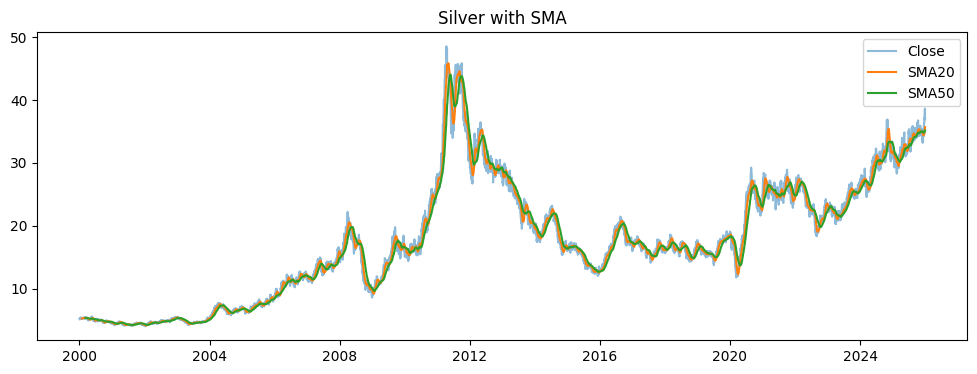


💾 Saved: silver_with_indicators.csv - Upload this to GitHub


In [2]:
import pandas as pd, glob, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

file = glob.glob('*silver*.csv')[0]
df = pd.read_csv(file)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# --- Returns ---
df['Daily_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close']/df['Close'].shift(1))

# --- 20 Technical Indicators (as per PDF) ---
# 1-4 SMA
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()
df['SMA_200'] = df['Close'].rolling(200).mean()
# 5-6 EMA
df['EMA_12'] = df['Close'].ewm(span=12).mean()
df['EMA_26'] = df['Close'].ewm(span=26).mean()
# 7 RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain/loss
df['RSI_14'] = 100 - (100/(1+rs))
# 8-10 MACD
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
# 11-13 Bollinger
df['BB_Mid'] = df['Close'].rolling(20).mean()
std = df['Close'].rolling(20).std()
df['BB_Upper'] = df['BB_Mid'] + 2*std
df['BB_Lower'] = df['BB_Mid'] - 2*std
# 14-15 Volatility, Momentum
df['Volatility_20'] = df['Log_Return'].rolling(20).std()
df['Momentum_10'] = df['Close'] - df['Close'].shift(10)
# 16-18 More
df['Price_Rate_of_Change'] = df['Close'].pct_change(12)*100
df['High_Low_Pct'] = (df['High']-df['Low'])/df['Close']*100
df['Close_SMA20_Dist'] = (df['Close']-df['SMA_20'])/df['SMA_20']*100
# 19-20 Volume indicators
df['Volume_SMA_20'] = df['Volume'].rolling(20).mean()
df['Volume_Ratio'] = df['Volume']/df['Volume_SMA_20']

print("✅ 20 Indicators Created")
print(df[['Close','SMA_20','RSI_14','MACD','BB_Upper','Volatility_20']].tail())

# --- Stationarity Test (ADF) - Required by PDF ---
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Close'].dropna())
print(f"\nADF Test on Close: Statistic={result[0]:.4f}, p-value={result[1]:.6f}")
print("Non-Stationary (need differencing)" if result[1]>0.05 else "Stationary")

result2 = adfuller(df['Log_Return'].dropna())
print(f"ADF Test on Log_Return: Statistic={result2[0]:.4f}, p-value={result2[1]:.6f}")
print("Non-Stationary" if result2[1]>0.05 else "✅ Stationary - Good for modeling")

# --- Chart 1: Price 2000-2025 ---
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Close'])
plt.title('Silver Price 2000-2025 (6783 days)')
plt.xlabel('Year'); plt.ylabel('Close Price')
plt.show()

# --- Chart 2: SMA ---
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.5)
plt.plot(df['Date'], df['SMA_20'], label='SMA20')
plt.plot(df['Date'], df['SMA_50'], label='SMA50')
plt.legend(); plt.title('Silver with SMA')
plt.show()

# Save final file for GitHub
df.to_csv('silver_with_indicators.csv', index=False)
print("\n💾 Saved: silver_with_indicators.csv - Upload this to GitHub")